In [1]:
%pwd

'c:\\Users\\rohit\\Desktop\\Files\\Projects\\CosmoFormer\\research'

In [2]:
%cd ..
%pwd

c:\Users\rohit\Desktop\Files\Projects\CosmoFormer


'c:\\Users\\rohit\\Desktop\\Files\\Projects\\CosmoFormer'

### Raw

In [3]:
import numpy as np
from src.utils.config_utils import load_config
from pathlib import Path

config_path = r"C:\Users\rohit\Desktop\Files\Projects\CosmoFormer\configs\config_2layer.yaml"
cfg = load_config(config_path)
raw_dir= Path(cfg["data"]["raw_dir"])
out_dir= Path(cfg["data"]["processed_dir"])
raw_true = np.load(f"{raw_dir}/true_cls_64_1k.npy")
raw_mixed = np.load(f"{raw_dir}/mixed_cls_64_1k.npy")
raw_noise = np.load(f"{raw_dir}/noise_cls_64_1k.npy")

print("raw true:", raw_true.shape)
print("raw mixed:", raw_mixed.shape)
print("raw noise:", raw_noise.shape)

raw true: (1000, 127)
raw mixed: (1000, 127)
raw noise: (1000, 127)


In [4]:
print("raw true mean:", raw_true.mean())
print("raw mixed mean:", raw_mixed.mean())
print("raw noise mean:", raw_noise.mean())
print()
print("raw true std:", raw_true.std())
print("raw mixed std:", raw_mixed.std())
print("raw noise std:", raw_noise.std())

raw true mean: 1924.3247101724248
raw mixed mean: 7748.409348788342
raw noise mean: 5827.759459497437

raw true std: 770.5693991563667
raw mixed std: 3589.799127819826
raw noise std: 4020.3380820073967


### Processed

In [5]:
import numpy as np

mean = np.load(f"{out_dir}/scaler_mean.npy")
std = np.load(f"{out_dir}/scaler_std.npy")
print("mean:", mean[0])
print("std:", std[0])

mean: 7750.867942561068
std: 3591.902765267444


In [6]:
X_train = np.load(f"{out_dir}/X_train.npy")
Y_true_train = np.load(f"{out_dir}/Y_true_train.npy")
Y_noise_train = np.load(f"{out_dir}/Y_noise_train.npy")

X_val = np.load(f"{out_dir}/X_val.npy")
Y_true_val = np.load(f"{out_dir}/Y_true_val.npy")
Y_noise_val = np.load(f"{out_dir}/Y_noise_val.npy")

print("X_train shape:", X_train.shape)
print("Y_true_train shape:", Y_true_train.shape)
print("Y_noise_train shape:", Y_noise_train.shape)
print()
print("X_val shape:", X_val.shape)
print("Y_true_val shape:", Y_true_val.shape)
print("Y_noise_val shape:", Y_noise_val.shape)

X_train shape: (800, 127)
Y_true_train shape: (800, 127)
Y_noise_train shape: (800, 127)

X_val shape: (200, 127)
Y_true_val shape: (200, 127)
Y_noise_val shape: (200, 127)


In [ ]:
print(f"X mean: {X_train.mean():.2f}")
print(f"X std: {X_train.std():.2f}")
print(f"Y_true mean: {Y_true_train.mean():.2f}")
print(f"Y_true std: {Y_true_train.std():.2f}")
print(f"Y_noise mean: {Y_noise_train.mean():.2f}")
print(f"Y_noise std: {Y_noise_train.std():.2f}")
print()
print(f"X_val mean: {X_val.mean():.2f}")
print(f"X_val std: {X_val.std():.2f}")
print(f"Y_true_val mean: {Y_true_val.mean():.2f}")
print(f"Y_true_val std: {Y_true_val.std():.2f}")
print(f"Y_noise_val mean: {Y_noise_val.mean():.2f}")
print(f"Y_noise_val std: {Y_noise_val.std():.2f}")

X mean: -0.00
X std: 1.00
Y_true mean: -1.51
Y_true std: 0.21
Y_noise mean: 1.12
Y_noise std: 1.12

X_val mean: 0.00
X_val std: 1.00
Y_true_val mean: -1.51
Y_true_val std: 0.21
Y_noise_val mean: -0.53
Y_noise_val std: 1.12


In [9]:
def inverse_transform(x):
    mean = np.load(f"{out_dir}/scaler_mean.npy")
    std = np.load(f"{out_dir}/scaler_std.npy")
    return x*std+mean

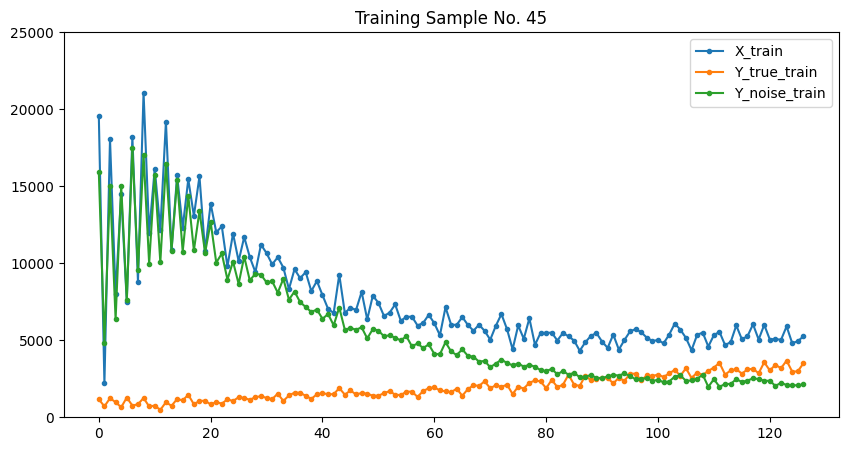

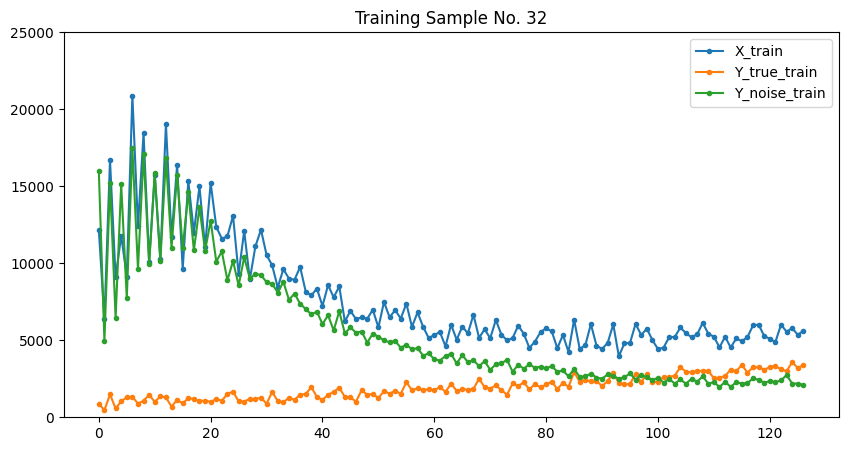

In [10]:
import matplotlib.pyplot as plt

sample_no = 45
plt.figure(figsize=(10, 5))
plt.plot(inverse_transform(X_train[sample_no]), label='X_train', marker='o', markersize=3)
plt.plot(inverse_transform(Y_true_train[sample_no]), label='Y_true_train', marker='o', markersize=3)
plt.plot(inverse_transform(Y_noise_train[sample_no]), label='Y_noise_train', marker='o', markersize=3)
plt.title(f"Training Sample No. {sample_no}")
plt.ylim(0, 25000)
plt.legend()

sample_no = 32
plt.figure(figsize=(10, 5))
plt.plot(inverse_transform(X_train[sample_no]), label='X_train', marker='o', markersize=3)
plt.plot(inverse_transform(Y_true_train[sample_no]), label='Y_true_train', marker='o', markersize=3)
plt.plot(inverse_transform(Y_noise_train[sample_no]), label='Y_noise_train', marker='o', markersize=3)
plt.title(f"Training Sample No. {sample_no}")
plt.ylim(0, 25000)
plt.legend()

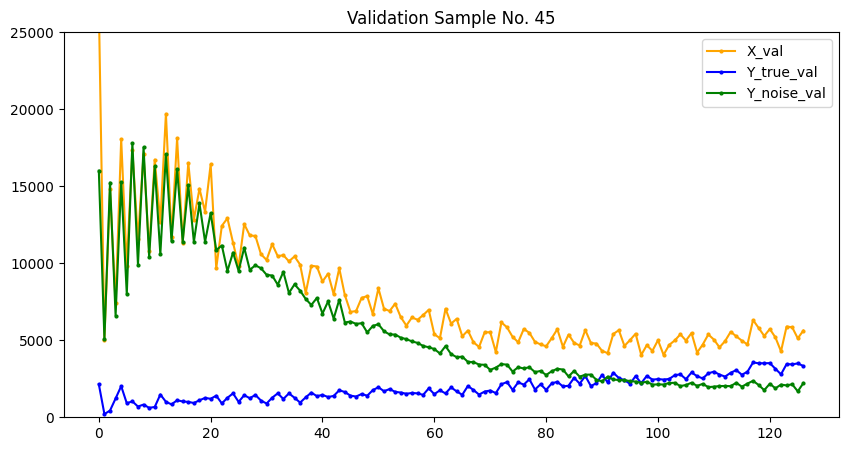

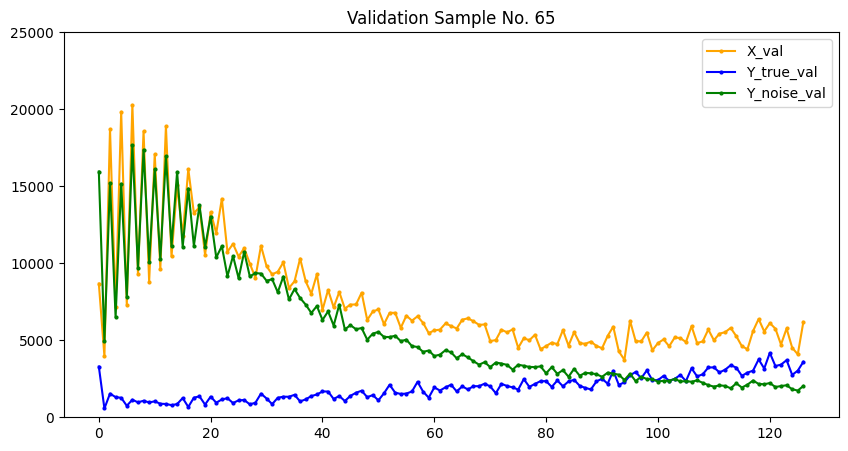

In [11]:
import matplotlib.pyplot as plt

sample_no = 45
plt.figure(figsize=(10, 5))
plt.plot(inverse_transform(X_val[sample_no]), label='X_val', marker='o', markersize=2, color='orange')
plt.plot(inverse_transform(Y_true_val[sample_no]), label='Y_true_val', marker='o', markersize=2, color='blue')
plt.plot(inverse_transform(Y_noise_val[sample_no]), label='Y_noise_val', marker='o', markersize=2, color = 'green')
plt.title(f"Validation Sample No. {sample_no}")
plt.ylim(0, 25000)
plt.legend()

sample_no = 65
plt.figure(figsize=(10, 5))
plt.plot(inverse_transform(X_val[sample_no]), label='X_val', marker='o', markersize=2, color='orange')
plt.plot(inverse_transform(Y_true_val[sample_no]), label='Y_true_val', marker='o', markersize=2, color='blue')
plt.plot(inverse_transform(Y_noise_val[sample_no]), label='Y_noise_val', marker='o', markersize=2, color = 'green')
plt.title(f"Validation Sample No. {sample_no}")
plt.ylim(0, 25000)
plt.legend()
